In [1]:
from flextrees.datasets.tabular_datasets import bank
from flextrees.datasets.tabular_datasets import nursery
from flextrees.datasets.tabular_datasets import adult
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.evaluation import FL_simple_cross_val_score
from sklearn.datasets import load_breast_cancer
import time
import math
from statds.no_parametrics import friedman, bonferroni, nemenyi
import os

In [2]:
train_data, test_data = bank(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_bank = np.concatenate((X_data,X_test)).astype(int) #Some were bools
targets_bank = np.concatenate((y_data,y_test))

In [3]:
train_data, test_data = adult(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_adult = np.concatenate((X_data,X_test))
targets_adult = np.concatenate((y_data,y_test))

In [4]:
train_data, test_data = nursery(ret_feature_names=False, categorical=False)
X_data,y_data = train_data.to_numpy()
X_test,y_test = test_data.to_numpy()
X_data_nursery = np.concatenate((X_data,X_test))
targets_nursery = np.concatenate((y_data,y_test))

In [5]:
breast_cancer = load_breast_cancer()
X_data_bcancer = breast_cancer.data
targets_bcancer = breast_cancer.target

In [6]:
def experiment3search(datasets,data_distribution,distribution_param = None,public_data_prediction='weighted_majority_voting',server_alpha_weight_adj='common_weighted'):

    #Algorithm parameters:
    Nclients = 10
    #server_alpha_weight_adj = 'own' 
    #prediction_weights = 'server_and_clients'
    T = 10
    adapt_client_weight1 = np.ones(Nclients)
    #Tuple containing if server or only server, if balanced to amount of data and if balanced to labels. 
    parameters = [('only_server',None,False),('server_and_clients',adapt_client_weight1,False),('server_and_clients',adapt_client_weight1,True),
                  ('server_and_clients',None,False),('server_and_clients',adapt_client_weight1,True)]
    parametersnames = ['only_server','s_cl_nb_nb','s_cl_nb_b','s_cl_b_nb','s_cl_b_b']
    #Default settings
    seeds =[0,142,242,342,442,542]
    parameterscolumns = ['only_server','only_server_std','s_cl_nb_nb','s_cl_nb_nb_std','s_cl_nb_b','s_cl_nb_b_std','s_cl_b_nb','s_cl_b_nb_std','s_cl_b_b','s_cl_b_b_std']

    #Creates dataframes to store avg results : FL on global data, FL on local data, centralized model scores (f1 and acc)
    dataframeacc_globaldata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframeacc_globaldata = dataframeacc_globaldata.rename_axis('FLGlobal_acc',axis=1)
    dataframef1_globaldata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframef1_globaldata = dataframef1_globaldata.rename_axis('FLGlobal_f1',axis=1)
    dataframeacc_localdata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframeacc_localdata = dataframeacc_localdata.rename_axis('FLlocal_acc',axis=1)
    dataframef1_localdata = pd.DataFrame(np.nan, index= datasets.keys(),
                            columns = parameterscolumns)
    dataframef1_localdata = dataframef1_localdata.rename_axis('FLlocal_f1',axis=1)
    dataframe_centralizedacc = pd.DataFrame(np.nan, index = datasets.keys(),columns = ['mean','std'])
    dataframe_centralizedacc = dataframe_centralizedacc.rename_axis('centralized_acc',axis=1)
    dataframe_centralizedf1 = pd.DataFrame(np.nan, index = datasets.keys(),columns = ['mean','std'])
    dataframe_centralizedf1 = dataframe_centralizedf1.rename_axis('centralized_f1',axis=1)

    acc_results = []
    f1_results = []

    #Training of 6 5-folds for each dataset and then gets stored in its corresponding row. 
    for dataset,data in datasets.items():
        data_to_mergeacc = [[]]*len(parameters)
        data_to_mergef1 = [[]]*len(parameters)
        centralized_acc = []
        centralized_f1 = []
        for seed in seeds:
            fulldata,fulltargets = data
            X_data,public_data,y_data,public_data_targets = train_test_split(fulldata,fulltargets,
                                                                            train_size=0.75,random_state=seed)
            #Create folds
            skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=seed)
            indices_iterable = skf.split(X_data,y_data)
            
            dataset_splits = [None]*5
            for i,(filter_train,filter_test) in enumerate(indices_iterable):
                dataset_splits[i] = (X_data[filter_train],X_data[filter_test],
                                    y_data[filter_train],y_data[filter_test])
            
            aux_acc_dataframe = pd.DataFrame(np.nan, index = [dataset+str(seed)]*len(dataset_splits),columns = parametersnames)
            aux_f1_dataframe = pd.DataFrame(np.nan, index = [dataset+str(seed)]*len(dataset_splits),columns = parametersnames) 
                
            for i,parameter in enumerate(parameters):
                prediction_weights,adapt_client_weight,balanced = parameter
                FLmodels,centralized_models,accDataFrames,F1DataFrames,acc_centralized_model_scores,f1_centralized_model_scores = FL_simple_cross_val_score(dataset_splits,
                                public_data,Nclients=Nclients,
                                public_data_prediction=public_data_prediction,server_alpha_weight_adj=server_alpha_weight_adj,
                                prediction_weights=prediction_weights,T=T,data_distribution=data_distribution,distribution_param=distribution_param,random_state=seed,
                                adapt_client_weight=adapt_client_weight,balanced_target_client_weight=balanced)
                for j,accDataFrame in enumerate(accDataFrames):
                    aux_acc_dataframe.iloc[j,i] = accDataFrame.loc[:]['FL_acc_global_data'].mean()
                    aux_f1_dataframe.iloc[j,i] = F1DataFrames[j].loc[:]['FL_acc_global_data'].mean()
                
                data_to_mergeacc[i] = data_to_mergeacc[i] + accDataFrames
                data_to_mergef1[i] = data_to_mergef1[i] + F1DataFrames
            
            acc_results.append(aux_acc_dataframe)
            f1_results.append(aux_f1_dataframe)

            #In each parameter the centralized score does not change, hence, we only store the last ones.
            centralized_acc = centralized_acc + acc_centralized_model_scores
            centralized_f1 = centralized_f1 + f1_centralized_model_scores
        #Once we've done all the tests in all the parameters and seeds for the given dataset, we store it in the dataframes and 
        #start with the next one
        for i in range(len(data_to_mergeacc)):
            data_to_mergeacc[i] = pd.concat(data_to_mergeacc[i],axis=0).describe().loc[['mean','std']][['FL_acc_own_data','FL_acc_global_data']]
            data_to_mergef1[i] = pd.concat(data_to_mergef1[i],axis=0).describe().loc[['mean','std']][['FL_acc_own_data','FL_acc_global_data']]
        
        arr_centralized_acc = np.array(centralized_acc)
        arr_centralized_f1 = np.array(centralized_f1)
        dataframeacc = pd.concat(data_to_mergeacc,axis=0)
        dataframef1 = pd.concat(data_to_mergef1,axis=0)
        dataframeacc_globaldata.loc[dataset] = dataframeacc.iloc[:,1].values
        dataframeacc_localdata.loc[dataset] = dataframeacc.iloc[:,0].values
        dataframef1_globaldata.loc[dataset] = dataframef1.iloc[:,1].values
        dataframef1_localdata.loc[dataset] = dataframef1.iloc[:,0].values
        dataframe_centralizedacc.loc[dataset] = (arr_centralized_acc.mean(),arr_centralized_acc.std())
        dataframe_centralizedf1.loc[dataset] = (arr_centralized_f1.mean(),arr_centralized_f1.std())

    statistics_acc = pd.concat(acc_results,axis=0)
    statistics_acc = statistics_acc.rename_axis('FL_global_acc')
    statistics_f1 = pd.concat(f1_results,axis=0)
    statistics_f1 = statistics_f1.rename_axis('FL_global_f1')
    return dataframeacc_globaldata,dataframeacc_localdata,dataframe_centralizedacc,dataframef1_globaldata,dataframef1_localdata,dataframe_centralizedf1,statistics_acc,statistics_f1

In [7]:
datasets = {'bank':(X_data_bank,targets_bank),
            'adult':(X_data_adult,targets_adult),'nursery':(X_data_nursery,targets_nursery),'bcancer':(X_data_bcancer,targets_bcancer)}

In [8]:
time0 = time.time()
iidresultsW_aw = experiment3search(data_distribution='iid',datasets=datasets,server_alpha_weight_adj='avg_weighted')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in iidresultsW_aw:
    print(result)

_,_,_,_,_,_,acc_results_cw,f1_results_cw = iidresultsW_aw
path = os.path.abspath('') + '\\exp3results\\AWiidacc'
acc_results_cw.round(decimals=3).reset_index(drop=True)
acc_results_cw.to_csv(path_or_buf=path)
path = os.path.abspath('') + '\\exp3results\\AWiidf1'
f1_results_cw.round(decimals=3).reset_index(drop=True)
f1_results_cw.to_csv(path_or_buf=path)


c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 21.828885312875112
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.914123         0.288209   85.004325        0.549706   
adult           84.726317         0.445936   80.174857        0.820446   
nursery         94.375857         0.512738   90.493141        1.225039   
bcancer         90.175103         3.691029   89.062882        4.268338   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          88.914123       0.288209  88.914123       0.288209  88.914123   
adult         83.955091       0.585887  84.726317       0.445936  83.955091   
nursery       90.561043       1.223743  94.375857       0.512738  90.561043   
bcancer       89.927360       3.756059  90.576653       3.342226  89.927360   

FLGlobal_acc  s_cl_b_b_std  
bank              0.288209  
adult             0.585887  
nursery           1.223743  
bcancer           3.756059  
FLlocal_acc  only_server  only_serv

In [11]:
time0 = time.time()
niidquantity_resultsW_aw = experiment3search(data_distribution='niid_quantity_skew',datasets=datasets,distribution_param=0.5,server_alpha_weight_adj='avg_weighted')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in niidquantity_resultsW_aw:
    print(result)

_,_,_,_,_,_,acc_results_cw,f1_results_cw = niidquantity_resultsW_aw
path = os.path.abspath('') + '\\exp3results\\AWniid_quantity_skew_acc'
acc_results_cw.round(decimals=3).reset_index(drop=True)
acc_results_cw.to_csv(path_or_buf=path)
path = os.path.abspath('') + '\\exp3results\\AWniid_quantity_skew_f1'
f1_results_cw.round(decimals=3).reset_index(drop=True)
f1_results_cw.to_csv(path_or_buf=path)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 21.267978620529174
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            87.732003         0.901467   84.813318        1.137751   
adult           82.999181         1.134303   79.135135        2.343857   
nursery         95.013717         1.199986   87.781550        7.881938   
bcancer         90.856680         4.028856   87.380347        6.754047   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          87.732003       0.901467  87.673413       1.002964  87.732003   
adult         82.648922       1.310270  83.047366       1.106808  82.648922   
nursery       88.994684       5.580230  95.025720       1.196094  88.994684   
bcancer       88.859097       5.769289  90.957820       4.132093  88.859097   

FLGlobal_acc  s_cl_b_b_std  
bank              0.901467  
adult             1.310270  
nursery           5.580230  
bcancer           5.769289  
FLlocal_acc  only_server  only_serv

In [12]:
time0 = time.time()
niidquantity_resultsW_aw = experiment3search(data_distribution='niid_dirichlet_label_skew',datasets=datasets,distribution_param=0.5,server_alpha_weight_adj='avg_weighted')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in niidquantity_resultsW_aw:
    print(result)

_,_,_,_,_,_,acc_results_cw,f1_results_cw = niidquantity_resultsW_aw
path = os.path.abspath('') + '\\exp3results\\AWniid_dirichlet_label_skew_acc'
acc_results_cw.round(decimals=3).reset_index(drop=True)
acc_results_cw.to_csv(path_or_buf=path)
path = os.path.abspath('') + '\\exp3results\\AWniid_dirichlet_label_skew_f1'
f1_results_cw.round(decimals=3).reset_index(drop=True)
f1_results_cw.to_csv(path_or_buf=path)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 17.74762785434723
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
bank            88.116717         0.356879   76.907418       21.410584   
adult           81.869028         2.521492   71.350805       17.283346   
nursery         93.043724         1.383072   70.109911       20.346642   
bcancer         85.955449         8.860044   71.375467       19.696153   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
bank          82.314499      15.608800  87.275620       6.457854  82.314499   
adult         77.298935      11.418671  80.762080       6.885040  77.298935   
nursery       84.717421      12.676400  91.945816       6.058289  84.717421   
bcancer       78.876243      16.451834  80.807615      14.912660  78.876243   

FLGlobal_acc  s_cl_b_b_std  
bank             15.608800  
adult            11.418671  
nursery          12.676400  
bcancer          16.451834  
FLlocal_acc  only_server  only_serve

In [13]:
datasets = {'nursery':(X_data_nursery,targets_nursery)}

In [14]:
time0 = time.time()
niidquantity_resultsW_aw = experiment3search(data_distribution='niid_label_quantity_skew',datasets=datasets,distribution_param=3,server_alpha_weight_adj='avg_weighted')
print("\n[INFO] Total Time (in minutes) =", (time.time() - time0) / 60)
for result in niidquantity_resultsW_aw:
    print(result)

_,_,_,_,_,_,acc_results_cw,f1_results_cw = niidquantity_resultsW_aw
path = os.path.abspath('') + '\\exp3results\\AWniid_label_quantity_skew_acc'
acc_results_cw.round(decimals=3).reset_index(drop=True)
acc_results_cw.to_csv(path_or_buf=path)
path = os.path.abspath('') + '\\exp3results\\AWniid_label_quantity_skew_f1'
f1_results_cw.round(decimals=3).reset_index(drop=True)
f1_results_cw.to_csv(path_or_buf=path)

c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\OneDrive\Escritorio\Programs\gitProjects\TFM_EnsembleFL\.venv\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mario\O


[INFO] Total Time (in minutes) = 2.771544408798218
FLGlobal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery         92.620542         1.384317   56.103224       19.975296   

FLGlobal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
nursery       74.744513      18.594211  91.057442       6.966974  74.744513   

FLGlobal_acc  s_cl_b_b_std  
nursery          18.594211  
FLlocal_acc  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery         90.46044        10.520935   95.128942          5.0095   

FLlocal_acc  s_cl_nb_b  s_cl_nb_b_std  s_cl_b_nb  s_cl_b_nb_std   s_cl_b_b  \
nursery      93.322446       6.460414  90.913402        10.4164  93.322446   

FLlocal_acc  s_cl_b_b_std  
nursery          6.460414  
centralized_acc       mean       std
nursery          99.218107  0.254928
FLGlobal_f1  only_server  only_server_std  s_cl_nb_nb  s_cl_nb_nb_std  \
nursery        93.046294         1.171623    66.56917       17.793049   

F

# IID Results

# Accuracy

In [29]:
dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\iidacc')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWiidacc')
dataframeextra.drop(['FL_global_acc'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [30]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1292.5544047619042, p-value 0.0
{'only_server_Wmv_cw': 5.208333333333333, 's_cl_nb_nb_Wmv_cw': 14.766666666666667, 's_cl_nb_b_Wmv_cw': 8.479166666666666, 's_cl_b_nb_Wmv_cw': 4.983333333333333, 's_cl_b_b_Wmv_cw': 8.479166666666666, 'only_server_Wmv_own': 7.129166666666666, 's_cl_nb_nb_Wmv_own': 14.0375, 's_cl_nb_b_Wmv_own': 8.754166666666666, 's_cl_b_nb_Wmv_own': 6.420833333333333, 's_cl_b_b_Wmv_own': 8.754166666666666, 'only_server_mv_cw': 18.4, 's_cl_nb_nb_mv_cw': 15.904166666666667, 's_cl_nb_b_mv_cw': 14.804166666666667, 's_cl_b_nb_mv_cw': 16.520833333333332, 's_cl_b_b_mv_cw': 14.804166666666667, 'only_server_Wmv_aw': 5.445833333333334, 's_cl_nb_nb_Wmv_aw': 14.829166666666667, 's_cl_nb_b_Wmv_aw': 8.583333333333334, 's_cl_b_nb_Wmv_aw': 5.1125, 's_cl_b_b_Wmv_aw': 8.583333333333334}


[5.208333333333333, 14.766666666666667, 8.479166666666666, 4.983333333333333, 8.479166666666666, 7.129166666666666, 14.0375, 8.754166666666666, 6.420833333333333, 8.754166666666666, 18.4, 15.904166666666667, 14.804166666666667, 16.520833333333332, 14.804166666666667, 5.445833333333334, 14.829166666666667, 8.583333333333334, 5.1125, 8.583333333333334]
2.7066214057637135


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


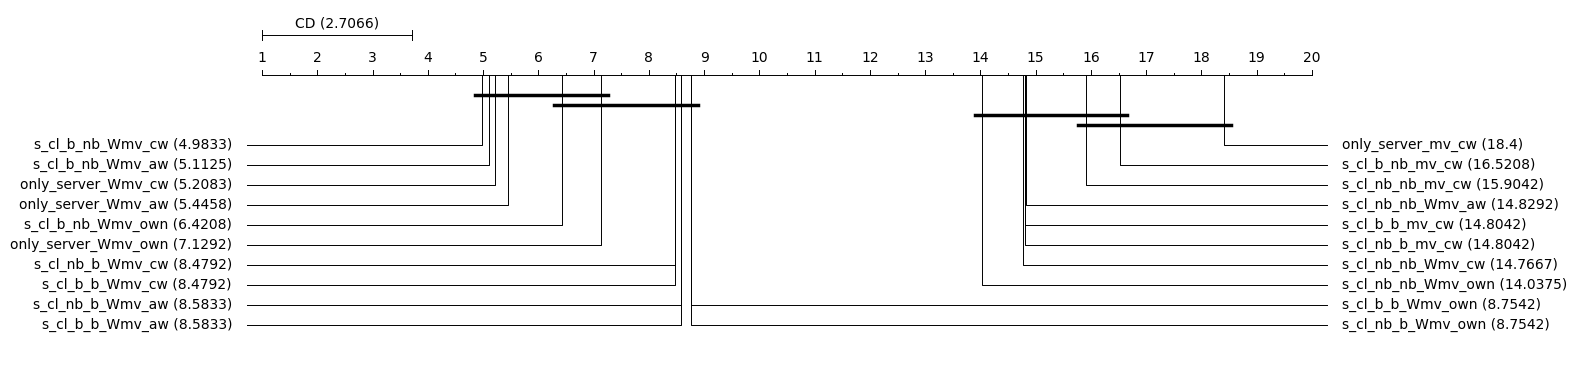

In [31]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      12.514796  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       4.282526  1.847835e-05   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.294594  7.683039e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       4.282526  1.847835e-05   
4    only_server_Wmv_cw vs only_server_Wmv_own       2.514961  1.190455e-02   
..                                         ...            ...           ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw      12.722103  0.000000e+00   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       8.177715  4.440892e-16   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       4.544388  5.509521e-06   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000e+00   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       4.544388  5.509521e-06   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


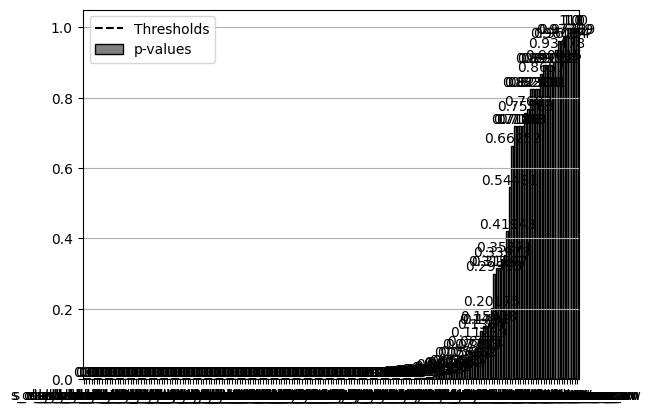

In [32]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1score

In [36]:

dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\iidf1')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWiidf1')
dataframeextra.drop(['FL_global_f1'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [37]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1356.1994047619046, p-value 0.0
{'only_server_Wmv_cw': 6.241666666666666, 's_cl_nb_nb_Wmv_cw': 14.7625, 's_cl_nb_b_Wmv_cw': 9.279166666666667, 's_cl_b_nb_Wmv_cw': 6.0, 's_cl_b_b_Wmv_cw': 9.279166666666667, 'only_server_Wmv_own': 8.104166666666666, 's_cl_nb_nb_Wmv_own': 14.0375, 's_cl_nb_b_Wmv_own': 9.554166666666667, 's_cl_b_nb_Wmv_own': 7.4625, 's_cl_b_b_Wmv_own': 9.554166666666667, 'only_server_mv_cw': 18.433333333333334, 's_cl_nb_nb_mv_cw': 15.8625, 's_cl_nb_b_mv_cw': 14.845833333333333, 's_cl_b_nb_mv_cw': 16.570833333333333, 's_cl_b_b_mv_cw': 14.845833333333333, 'only_server_Wmv_aw': 4.408333333333333, 's_cl_nb_nb_Wmv_aw': 14.916666666666666, 's_cl_nb_b_Wmv_aw': 5.870833333333334, 's_cl_b_nb_Wmv_aw': 4.1, 's_cl_b_b_Wmv_aw': 5.870833333333334}


[6.241666666666666, 14.7625, 9.279166666666667, 6.0, 9.279166666666667, 8.104166666666666, 14.0375, 9.554166666666667, 7.4625, 9.554166666666667, 18.433333333333334, 15.8625, 14.845833333333333, 16.570833333333333, 14.845833333333333, 4.408333333333333, 14.916666666666666, 5.870833333333334, 4.1, 5.870833333333334]
2.7066214057637135


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


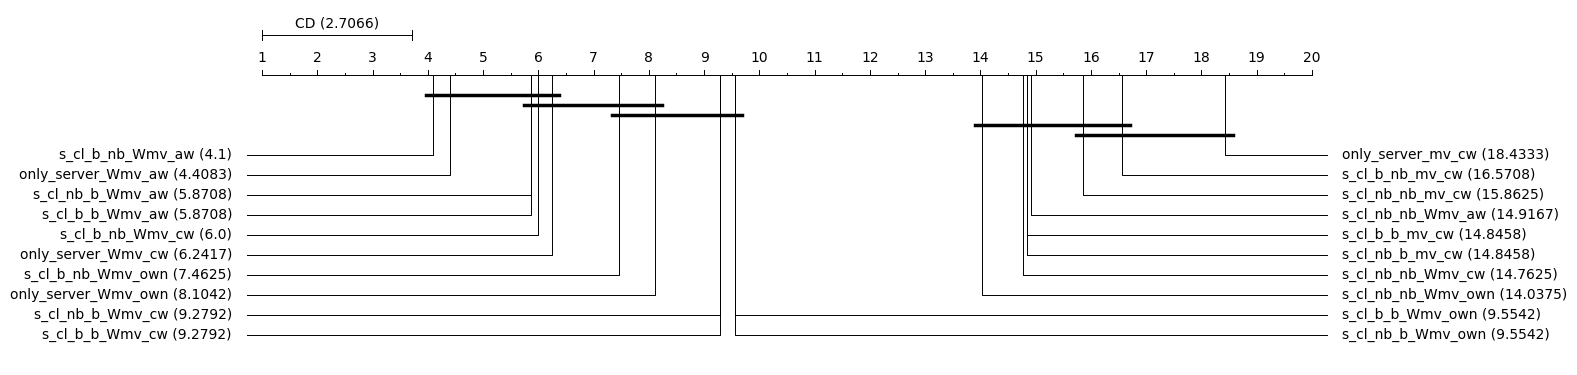

In [38]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)   p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      11.156390  0.000000   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       3.977021  0.000070   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.316416  0.751687   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       3.977021  0.000070   
4    only_server_Wmv_cw vs only_server_Wmv_own       2.438585  0.014745   
..                                         ...            ...       ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw      14.162341  0.000000   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw      11.843776  0.000000   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       2.318565  0.020419   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       2.318565  0.020419   

     Adjusted alpha  Adjusted p-value  alpha            Results  
0          0.000263          0.00

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\37423673.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


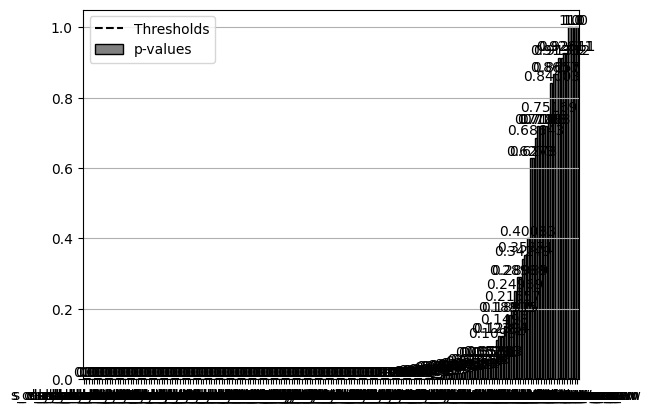

In [39]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()



# NIID Quantity skew

# Accuracy

In [40]:
dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\niid_quantity_skewacc')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWniid_quantity_skew_acc')
dataframeextra.drop(['FL_global_acc'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [41]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1035.0978571428568, p-value 0.0
{'only_server_Wmv_cw': 5.020833333333333, 's_cl_nb_nb_Wmv_cw': 15.366666666666667, 's_cl_nb_b_Wmv_cw': 8.45, 's_cl_b_nb_Wmv_cw': 5.095833333333333, 's_cl_b_b_Wmv_cw': 8.45, 'only_server_Wmv_own': 8.35, 's_cl_nb_nb_Wmv_own': 14.770833333333334, 's_cl_nb_b_Wmv_own': 9.658333333333333, 's_cl_b_nb_Wmv_own': 7.541666666666667, 's_cl_b_b_Wmv_own': 9.658333333333333, 'only_server_mv_cw': 16.3125, 's_cl_nb_nb_mv_cw': 16.483333333333334, 's_cl_nb_b_mv_cw': 13.075, 's_cl_b_nb_mv_cw': 14.883333333333333, 's_cl_b_b_mv_cw': 13.075, 'only_server_Wmv_aw': 5.525, 's_cl_nb_nb_Wmv_aw': 15.075, 's_cl_nb_b_Wmv_aw': 8.808333333333334, 's_cl_b_nb_Wmv_aw': 5.591666666666667, 's_cl_b_b_Wmv_aw': 8.808333333333334}


[5.020833333333333, 15.366666666666667, 8.45, 5.095833333333333, 8.45, 8.35, 14.770833333333334, 9.658333333333333, 7.541666666666667, 9.658333333333333, 16.3125, 16.483333333333334, 13.075, 14.883333333333333, 13.075, 5.525, 15.075, 8.808333333333334, 5.591666666666667, 8.808333333333334]
2.7066214057637135


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


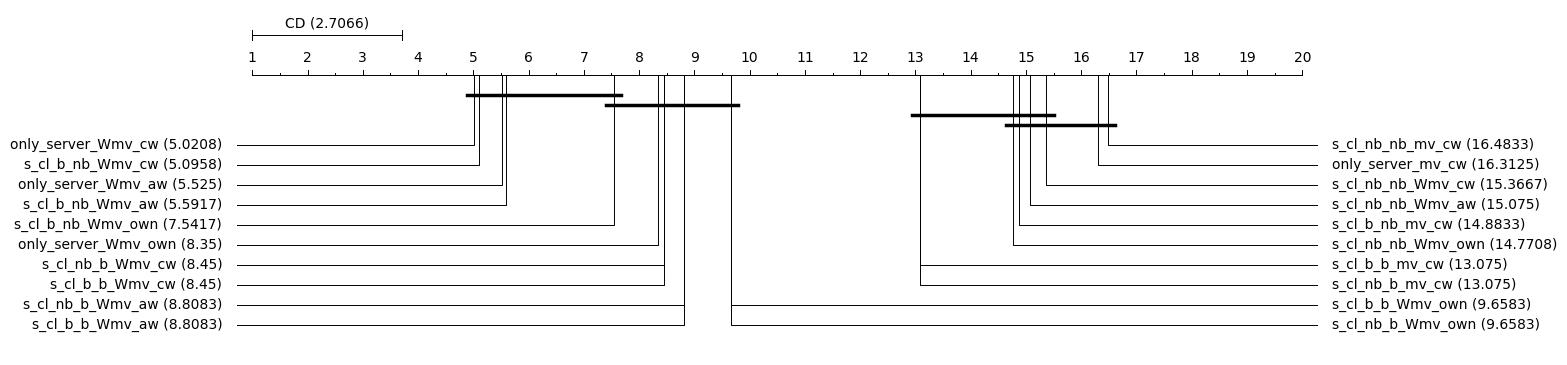

In [42]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      13.545876  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       4.489833  7.127900e-06   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.098198  9.217750e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       4.489833  7.127900e-06   
4    only_server_Wmv_cw vs only_server_Wmv_own       4.358902  1.307164e-05   
..                                         ...            ...           ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw      12.416598  0.000000e+00   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       8.204993  2.220446e-16   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       4.211605  2.535623e-05   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000e+00   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       4.211605  2.535623e-05   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


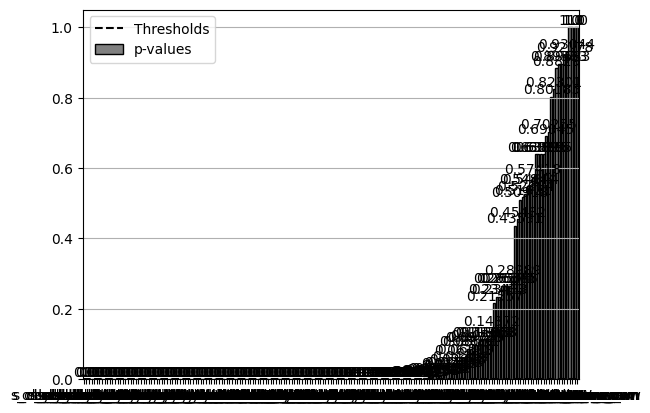

In [43]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1score

In [44]:

dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\niid_quantity_skewf1')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWniid_quantity_skew_f1')
dataframeextra.drop(['FL_global_f1'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [45]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1165.688452380953, p-value 0.0
{'only_server_Wmv_cw': 5.729166666666667, 's_cl_nb_nb_Wmv_cw': 15.508333333333333, 's_cl_nb_b_Wmv_cw': 9.15, 's_cl_b_nb_Wmv_cw': 5.8375, 's_cl_b_b_Wmv_cw': 9.15, 'only_server_Wmv_own': 9.066666666666666, 's_cl_nb_nb_Wmv_own': 14.8375, 's_cl_nb_b_Wmv_own': 10.258333333333333, 's_cl_b_nb_Wmv_own': 8.275, 's_cl_b_b_Wmv_own': 10.258333333333333, 'only_server_mv_cw': 16.670833333333334, 's_cl_nb_nb_mv_cw': 16.541666666666668, 's_cl_nb_b_mv_cw': 13.516666666666667, 's_cl_b_nb_mv_cw': 15.3, 's_cl_b_b_mv_cw': 13.516666666666667, 'only_server_Wmv_aw': 4.725, 's_cl_nb_nb_Wmv_aw': 14.783333333333333, 's_cl_nb_b_Wmv_aw': 6.204166666666667, 's_cl_b_nb_Wmv_aw': 4.466666666666667, 's_cl_b_b_Wmv_aw': 6.204166666666667}


[5.729166666666667, 15.508333333333333, 9.15, 5.8375, 9.15, 9.066666666666666, 14.8375, 10.258333333333333, 8.275, 10.258333333333333, 16.670833333333334, 16.541666666666668, 13.516666666666667, 15.3, 13.516666666666667, 4.725, 14.783333333333333, 6.204166666666667, 4.466666666666667, 6.204166666666667]
2.7066214057637135


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


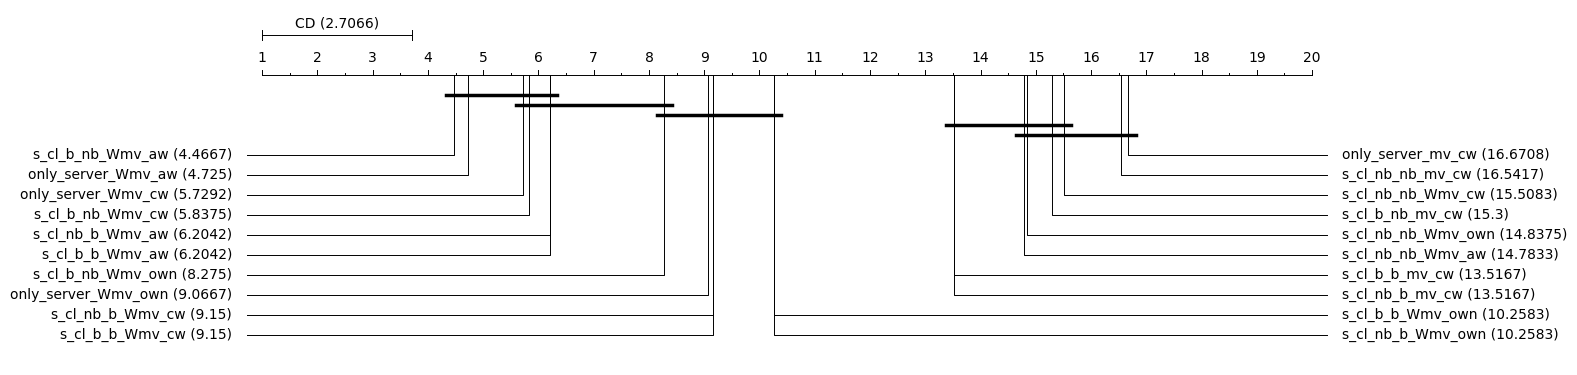

In [46]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)   p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      12.803935  0.000000   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       4.478922  0.000008   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.141842  0.887205   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       4.478922  0.000008   
4    only_server_Wmv_cw vs only_server_Wmv_own       4.369813  0.000012   
..                                         ...            ...       ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw      13.507687  0.000000   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw      11.232766  0.000000   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       2.274922  0.022911   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       2.274922  0.022911   

     Adjusted alpha  Adjusted p-value  alpha            Results  
0          0.000263          0.00

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


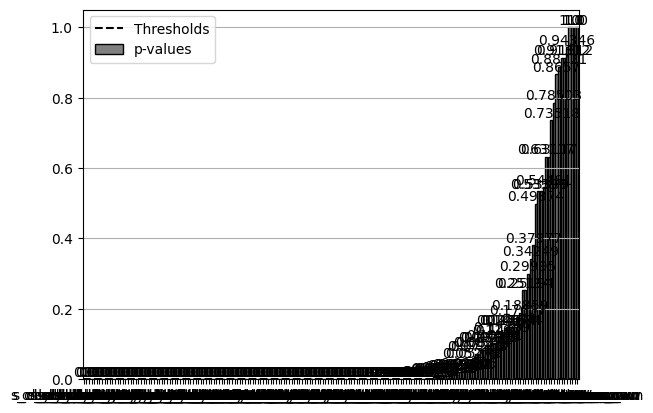

In [47]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# NIID label dirichlet skew

# Accuracy

In [50]:
dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\niid_dirichlet_label_skewacc')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWniid_dirichlet_label_skew_acc')
dataframeextra.drop(['FL_global_acc'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [51]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1518.891785714286, p-value 0.0
{'only_server_Wmv_cw': 2.7125, 's_cl_nb_nb_Wmv_cw': 17.329166666666666, 's_cl_nb_b_Wmv_cw': 7.479166666666667, 's_cl_b_nb_Wmv_cw': 3.8666666666666667, 's_cl_b_b_Wmv_cw': 7.479166666666667, 'only_server_Wmv_own': 4.283333333333333, 's_cl_nb_nb_Wmv_own': 18.2, 's_cl_nb_b_Wmv_own': 12.783333333333333, 's_cl_b_nb_Wmv_own': 10.354166666666666, 's_cl_b_b_Wmv_own': 12.783333333333333, 'only_server_mv_cw': 13.808333333333334, 's_cl_nb_nb_mv_cw': 15.783333333333333, 's_cl_nb_b_mv_cw': 12.4625, 's_cl_b_nb_mv_cw': 11.966666666666667, 's_cl_b_b_mv_cw': 12.4625, 'only_server_Wmv_aw': 3.529166666666667, 's_cl_nb_nb_Wmv_aw': 17.245833333333334, 's_cl_nb_b_Wmv_aw': 9.791666666666666, 's_cl_b_nb_Wmv_aw': 5.8875, 's_cl_b_b_Wmv_aw': 9.791666666666666}


[2.7125, 17.329166666666666, 7.479166666666667, 3.8666666666666667, 7.479166666666667, 4.283333333333333, 18.2, 12.783333333333333, 10.354166666666666, 12.783333333333333, 13.808333333333334, 15.783333333333333, 12.4625, 11.966666666666667, 12.4625, 3.529166666666667, 17.245833333333334, 9.791666666666666, 5.8875, 9.791666666666666]
2.7066214057637135


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


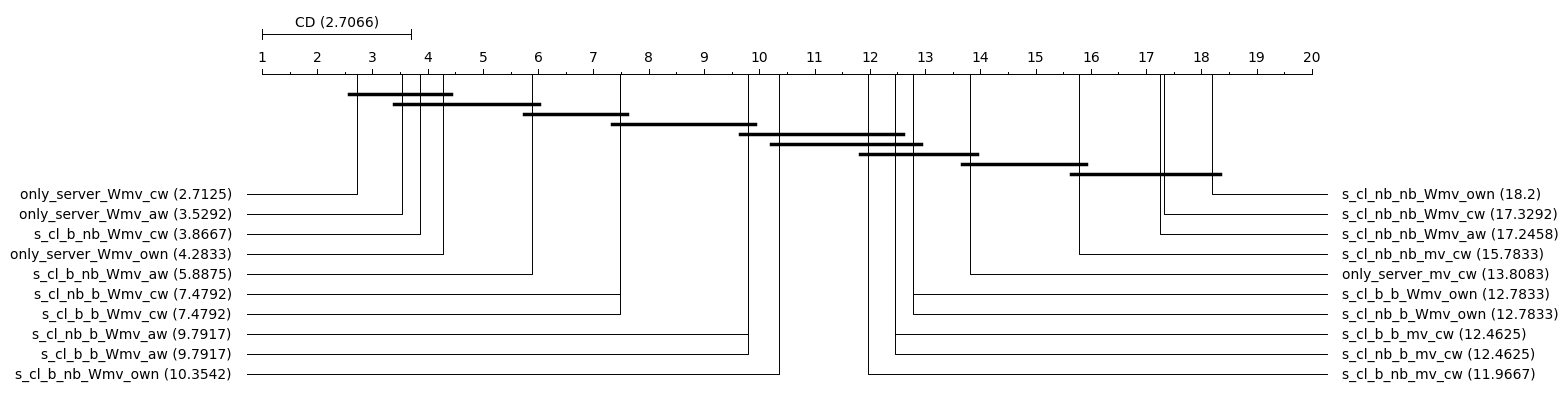

In [52]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      19.137709  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       6.241032  4.346943e-10   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       1.511159  1.307480e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       6.241032  4.346943e-10   
4    only_server_Wmv_cw vs only_server_Wmv_own       2.056704  3.971474e-02   
..                                         ...            ...           ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw      14.871549  0.000000e+00   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       9.759795  0.000000e+00   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       5.111754  3.191812e-07   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000e+00   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       5.111754  3.191812e-07   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


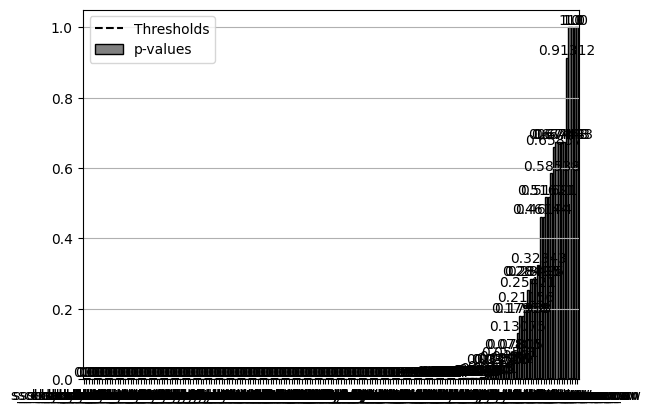

In [53]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1score

In [54]:

dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\niid_dirichlet_label_skewf1')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWniid_dirichlet_label_skew_f1')
dataframeextra.drop(['FL_global_f1'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [55]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 1591.4486904761907, p-value 0.0
{'only_server_Wmv_cw': 3.4208333333333334, 's_cl_nb_nb_Wmv_cw': 17.75, 's_cl_nb_b_Wmv_cw': 8.6875, 's_cl_b_nb_Wmv_cw': 4.966666666666667, 's_cl_b_b_Wmv_cw': 8.6875, 'only_server_Wmv_own': 5.325, 's_cl_nb_nb_Wmv_own': 18.491666666666667, 's_cl_nb_b_Wmv_own': 13.441666666666666, 's_cl_b_nb_Wmv_own': 10.995833333333334, 's_cl_b_b_Wmv_own': 13.441666666666666, 'only_server_mv_cw': 14.55, 's_cl_nb_nb_mv_cw': 16.325, 's_cl_nb_b_mv_cw': 13.195833333333333, 's_cl_b_nb_mv_cw': 12.958333333333334, 's_cl_b_b_mv_cw': 13.195833333333333, 'only_server_Wmv_aw': 1.9708333333333334, 's_cl_nb_nb_Wmv_aw': 13.683333333333334, 's_cl_nb_b_Wmv_aw': 7.5625, 's_cl_b_nb_Wmv_aw': 3.7875, 's_cl_b_b_Wmv_aw': 7.5625}


[3.4208333333333334, 17.75, 8.6875, 4.966666666666667, 8.6875, 5.325, 18.491666666666667, 13.441666666666666, 10.995833333333334, 13.441666666666666, 14.55, 16.325, 13.195833333333333, 12.958333333333334, 13.195833333333333, 1.9708333333333334, 13.683333333333334, 7.5625, 3.7875, 7.5625]
2.7066214057637135


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


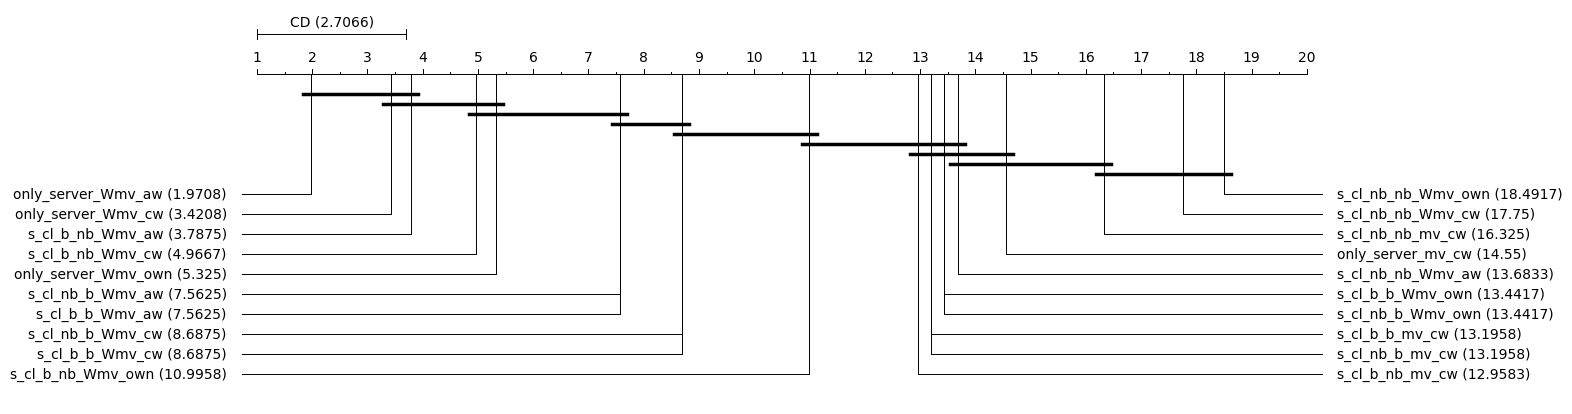

In [56]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw      18.761283  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       6.895685  5.360601e-12   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       2.023971  4.297314e-02   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       6.895685  5.360601e-12   
4    only_server_Wmv_cw vs only_server_Wmv_own       2.493139  1.266191e-02   
..                                         ...            ...           ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw      12.956687  0.000000e+00   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       8.014052  1.110223e-15   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       4.942635  7.707361e-07   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000e+00   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       4.942635  7.707361e-07   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


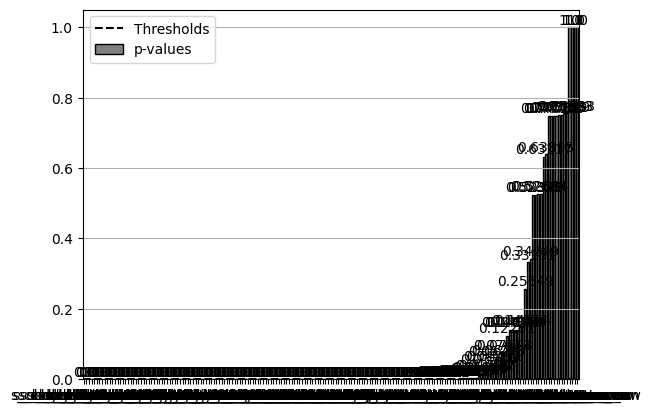

In [57]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# NIID quantity dirichlet skew

# Accuracy

In [58]:
dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\niid_label_quantity_skewacc')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWniid_label_quantity_skew_acc')
dataframeextra.drop(['FL_global_acc'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [59]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 529.962857142857, p-value 1.9574875054217955e-10
{'only_server_Wmv_cw': 2.1666666666666665, 's_cl_nb_nb_Wmv_cw': 14.833333333333334, 's_cl_nb_b_Wmv_cw': 9.316666666666666, 's_cl_b_nb_Wmv_cw': 3.066666666666667, 's_cl_b_b_Wmv_cw': 9.316666666666666, 'only_server_Wmv_own': 3.3666666666666667, 's_cl_nb_nb_Wmv_own': 15.033333333333333, 's_cl_nb_b_Wmv_own': 9.95, 's_cl_b_nb_Wmv_own': 5.1, 's_cl_b_b_Wmv_own': 9.95, 'only_server_mv_cw': 20.0, 's_cl_nb_nb_mv_cw': 14.166666666666666, 's_cl_nb_b_mv_cw': 16.5, 's_cl_b_nb_mv_cw': 18.766666666666666, 's_cl_b_b_mv_cw': 16.5, 'only_server_Wmv_aw': 3.0, 's_cl_nb_nb_Wmv_aw': 15.933333333333334, 's_cl_nb_b_Wmv_aw': 9.366666666666667, 's_cl_b_nb_Wmv_aw': 4.3, 's_cl_b_b_Wmv_aw': 9.366666666666667}


[2.1666666666666665, 14.833333333333334, 9.316666666666666, 3.066666666666667, 9.316666666666666, 3.3666666666666667, 15.033333333333333, 9.95, 5.1, 9.95, 20.0, 14.166666666666666, 16.5, 18.766666666666666, 16.5, 3.0, 15.933333333333334, 9.366666666666667, 4.3, 9.366666666666667]
5.413242811527427


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


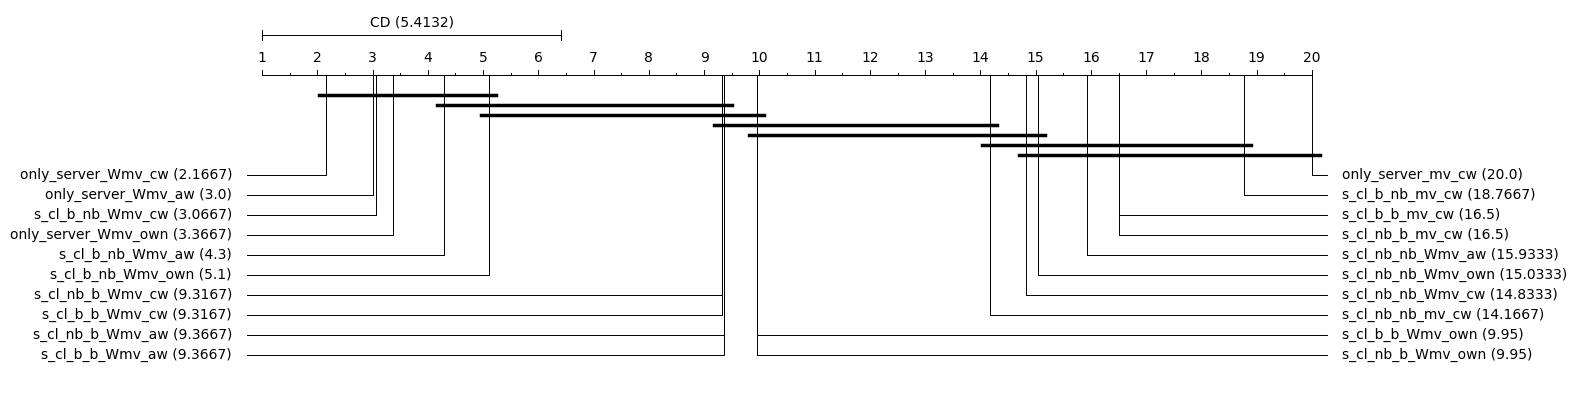

In [60]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw       8.292280  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       4.680774  2.857942e-06   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.589188  5.557350e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       4.680774  2.857942e-06   
4    only_server_Wmv_cw vs only_server_Wmv_own       0.785584  4.321110e-01   
..                                         ...            ...           ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw       7.615804  2.620126e-14   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       4.298892  1.716537e-05   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       3.316912  9.101830e-04   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000e+00   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       3.316912  9.101830e-04   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


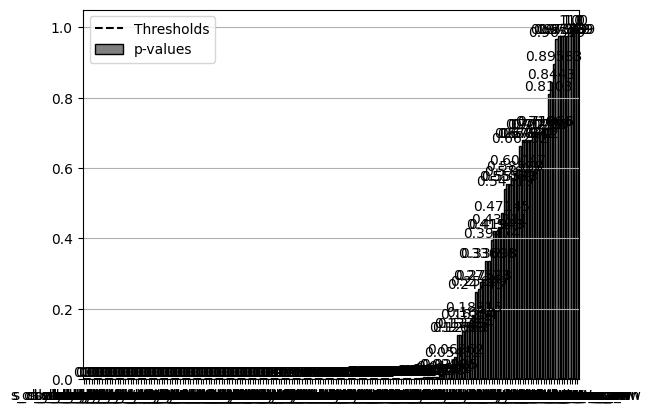

In [61]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()


# F1Score

In [62]:

dataframe = pd.read_csv(os.path.abspath('')+'\\exp3results\\niid_label_quantity_skewf1')
dataframe.drop(['Unnamed: 0'],axis='columns',inplace=True)
dataframeextra = pd.read_csv(os.path.abspath('')+'\\exp3results\\AWniid_label_quantity_skew_f1')
dataframeextra.drop(['FL_global_f1'],axis='columns',inplace=True)
dataframeextra.columns = dataframeextra.columns + '_Wmv_aw'
dataframeextra.round(decimals=3)
fulldata = pd.concat([dataframe,dataframeextra],axis=1)


In [63]:

alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(fulldata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 535.2733333333335, p-value 2.0736568018264734e-10
{'only_server_Wmv_cw': 2.566666666666667, 's_cl_nb_nb_Wmv_cw': 15.2, 's_cl_nb_b_Wmv_cw': 10.183333333333334, 's_cl_b_nb_Wmv_cw': 3.4, 's_cl_b_b_Wmv_cw': 10.183333333333334, 'only_server_Wmv_own': 3.6666666666666665, 's_cl_nb_nb_Wmv_own': 15.433333333333334, 's_cl_nb_b_Wmv_own': 10.65, 's_cl_b_nb_Wmv_own': 5.3, 's_cl_b_b_Wmv_own': 10.65, 'only_server_mv_cw': 20.0, 's_cl_nb_nb_mv_cw': 14.666666666666666, 's_cl_nb_b_mv_cw': 16.833333333333332, 's_cl_b_nb_mv_cw': 18.833333333333332, 's_cl_b_b_mv_cw': 16.833333333333332, 'only_server_Wmv_aw': 2.3333333333333335, 's_cl_nb_nb_Wmv_aw': 13.466666666666667, 's_cl_nb_b_Wmv_aw': 8.033333333333333, 's_cl_b_nb_Wmv_aw': 3.7333333333333334, 's_cl_b_b_Wmv_aw': 8.033333333333333}


[2.566666666666667, 15.2, 10.183333333333334, 3.4, 10.183333333333334, 3.6666666666666665, 15.433333333333334, 10.65, 5.3, 10.65, 20.0, 14.666666666666666, 16.833333333333332, 18.833333333333332, 16.833333333333332, 2.3333333333333335, 13.466666666666667, 8.033333333333333, 3.7333333333333334, 8.033333333333333]
5.413242811527427


C:\Users\mario\AppData\Local\Temp\ipykernel_14728\1926272719.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


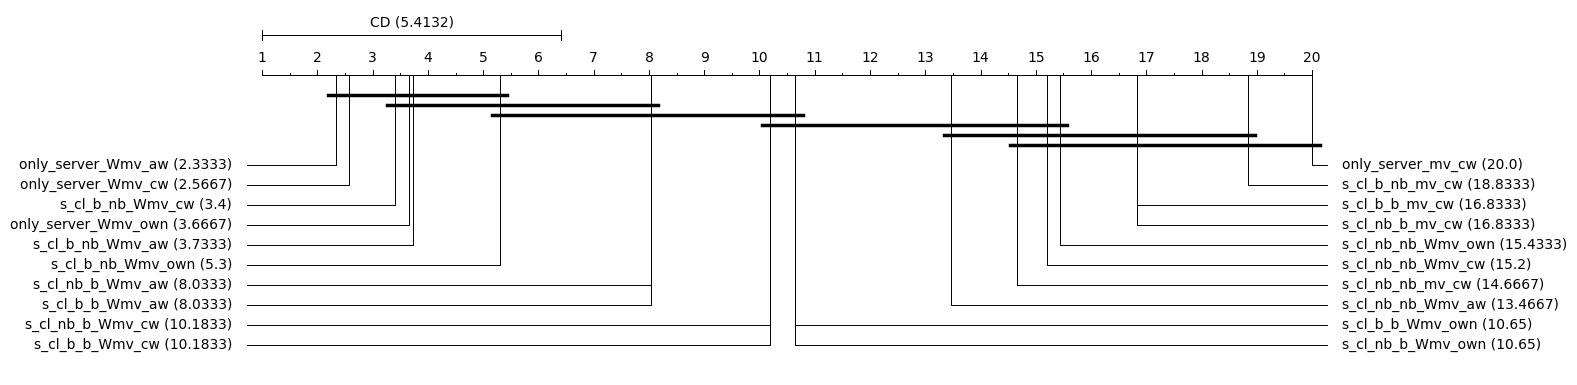

In [64]:

num_cases = fulldata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


                                    Comparison  Statistic (Z)       p-value  \
0      only_server_Wmv_cw vs s_cl_nb_nb_Wmv_cw       8.270458  0.000000e+00   
1       only_server_Wmv_cw vs s_cl_nb_b_Wmv_cw       4.986279  6.155331e-07   
2       only_server_Wmv_cw vs s_cl_b_nb_Wmv_cw       0.545545  5.853789e-01   
3        only_server_Wmv_cw vs s_cl_b_b_Wmv_cw       4.986279  6.155331e-07   
4    only_server_Wmv_cw vs only_server_Wmv_own       0.720119  4.714517e-01   
..                                         ...            ...           ...   
185      s_cl_nb_nb_Wmv_aw vs s_cl_b_nb_Wmv_aw       6.371962  1.866245e-10   
186       s_cl_nb_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       3.556952  3.751832e-04   
187       s_cl_nb_b_Wmv_aw vs s_cl_b_nb_Wmv_aw       2.815011  4.877560e-03   
188        s_cl_nb_b_Wmv_aw vs s_cl_b_b_Wmv_aw       0.000000  1.000000e+00   
189        s_cl_b_nb_Wmv_aw vs s_cl_b_b_Wmv_aw       2.815011  4.877560e-03   

     Adjusted alpha  Adjusted p-value  alpha       

C:\Users\mario\AppData\Local\Temp\ipykernel_14728\844582222.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


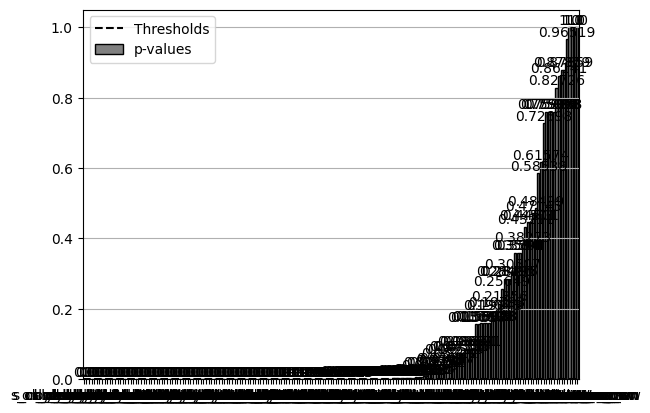

In [65]:

results, figure = bonferroni(rankings, num_cases, alpha, control = None, type_rank = "Friedman")
print(results)
figure.show()
